In [ ]:
import scanpy as sc
import numpy as np
import seaborn as sns
from scipy.stats import median_abs_deviation

In [3]:
# Load the last checkpoint
processed_data_path = "../data/processed"
adata = sc.read_h5ad(f"{processed_data_path}/01_load_qc.h5ad")

In [5]:
# MAD
def is_outlier(adata, metric: str, nmads: int):
    
    M = adata.obs[metric]
    
    # "median_abs_deviation()" computes the "unit of spread" for the choosen metric.
    # np.median() ± nmads * median_abs_deviation() determines the boundary for defining outliers
    median = np.median(M)
    m_abs_dev = median_abs_deviation(M)

    # Define the permissive range.
    lower_bound = median - (nmads * m_abs_dev)
    upper_bound = median + (nmads * m_abs_dev)
    outlier = (M < lower_bound) | (M > upper_bound)

    return outlier

In [6]:
# Setting "nmads = 5" is more conservative.
# The spread (MAD) is massive due to the presence of monster cells (or multiplet artefacts).
    # Thus, 5MADs of raw data may unwantedly include extreme data points.
adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5)
)
adata.obs.outlier.value_counts()

outlier
False    3500
True       55
Name: count, dtype: int64

In [7]:
# Computate the statistical outliers (MAD-based).
mt_outlier_mad = is_outlier(adata, "pct_counts_mt", 3)
# Apply the hard limit.
mt_outlier_percent = adata.obs["pct_counts_mt"] > 8

adata.obs["mt_outlier"] = mt_outlier_mad | mt_outlier_percent
adata.obs.mt_outlier.value_counts()

mt_outlier
False    3273
True      282
Name: count, dtype: int64

In [8]:
# A cell is "valid" only if it is NOT a general outlier AND NOT an MT outlier.
valid_cells = (~adata.obs.outlier) & (~adata.obs.mt_outlier)

# Record the cell numbers before and after filtering out low quality cells.
n_cells_before_filtering = adata.n_obs
adata = adata[valid_cells].copy()
n_cells_after_filtering = adata.n_obs

print(f"Number of cells before filtering: {n_cells_before_filtering}")
print(f"Number of cells after filtering: {n_cells_after_filtering}")

# "Freeze" the raw UMI integers after cleaning the cells but before we lose any or change numbers into decimals (due to normalisation)
# Downstream "normalisation" steps will permanently change "adata.X" into non-integer values.
# We want to keep integers because most tools later rely on models of whole numbers as underlying math.
adata.layers["raw_counts"] = adata.X.copy()

Number of cells before filtering: 3555
Number of cells after filtering: 3229


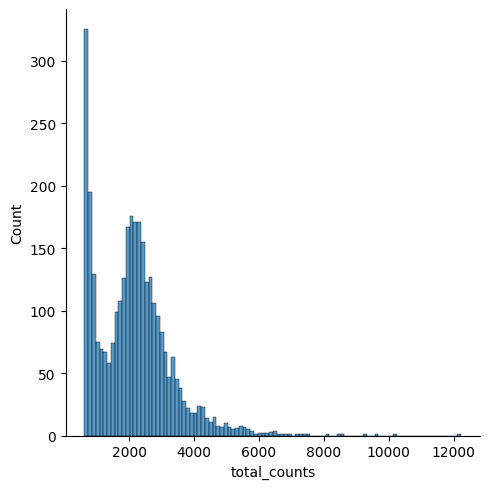

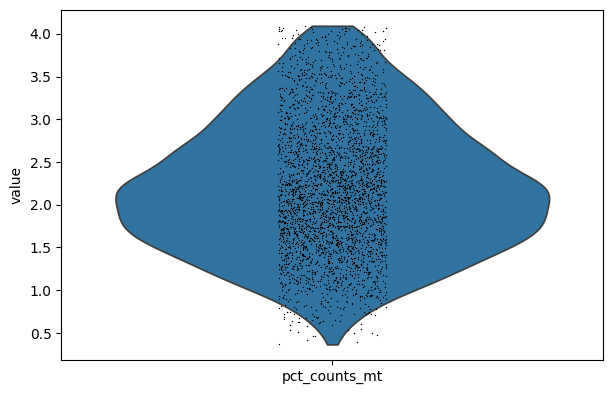

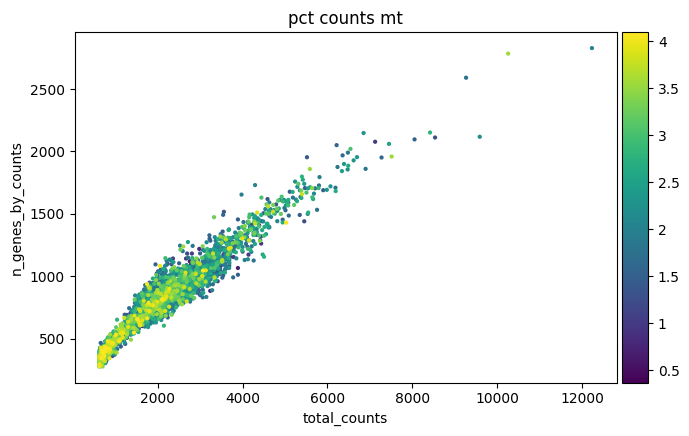

In [9]:
# Re-examine the data after filtering out low quality cells.
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [10]:
# Filter out genes that are detected in fewer than 3 cells.
n_genes_before_gene_filtering = adata.n_vars
sc.pp.filter_genes(adata, min_cells=3)
n_genes_after_gene_filtering = adata.n_vars

n_genes_removed = n_genes_before_gene_filtering - n_genes_after_gene_filtering
print(f"Genes before gene filtering: {n_genes_before_gene_filtering}")
print(f"Genes after gene filtering: {n_genes_after_gene_filtering}")

Genes before gene filtering: 61552
Genes after gene filtering: 16566


In [ ]:
# Save checkpoint.
adata.write_h5ad(f"{processed_data_path}/02_cell_gene_filtering.h5ad")